# importing libraries

In [63]:
import os
import urllib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sqlalchemy import create_engine

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.metrics import silhouette_score
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import (
    LabelEncoder,
    RobustScaler,
    StandardScaler,
)
from sklearn.metrics.pairwise import cosine_similarity

# Loading Data from SQL 

In [2]:
file_name = "Customer_segmentation_dataset_sample.csv"

if os.path.exists(file_name):
    print("CSV file found. Loading from disk...")
    df = pd.read_csv(file_name)

else:
    print("CSV file not found. Loading from SQL Server...")

    params = urllib.parse.quote_plus(
        "DRIVER={ODBC Driver 17 for SQL Server};"
        "SERVER=localhost\\SQLEXPRESS;"
        "DATABASE=Instacart;"
        "Trusted_Connection=yes;"
        "TrustServerCertificate=yes;"
    )

    engine = create_engine(f"mssql+pyodbc:///?odbc_connect={params}")

    query = """
    SELECT *
    FROM Customer_segmentation_dataset
    """

    df = pd.read_sql(query, engine)

    df.to_csv(file_name, index=False)

    print(f"Dataset saved as '{file_name}'")

print(df.shape)
display(df.head())

CSV file found. Loading from disk...
(739316, 12)


,user_id,order_id,product_id,order_number,order_dow,order_hour_of_day,days_since_prior_order,add_to_cart_order,reordered,product_name,department,aisle
0,51849,406,1376,5,5,9,19.0,17,0,Buttermilk Biscuits,pantry,doughs gelatins bake mixes
1,51849,406,4421,5,5,9,19.0,16,1,Organic Beef Uncured Hot Dogs,meat seafood,hot dogs bacon sausage
2,51849,406,5337,5,5,9,19.0,8,1,Monterey Jack Cheese,dairy eggs,packaged cheese
3,51849,406,6615,5,5,9,19.0,6,1,Mozzarella Cheese,dairy eggs,packaged cheese
4,51849,406,11644,5,5,9,19.0,20,0,Light In Sodium Beans and Rice Burrito,frozen,frozen meals


# Data preprocessing

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 739316 entries, 0 to 739315
Data columns (total 12 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   user_id                 739316 non-null  int64  
 1   order_id                739316 non-null  int64  
 2   product_id              739316 non-null  int64  
 3   order_number            739316 non-null  int64  
 4   order_dow               739316 non-null  int64  
 5   order_hour_of_day       739316 non-null  int64  
 6   days_since_prior_order  739316 non-null  float64
 7   add_to_cart_order       739316 non-null  int64  
 8   reordered               739316 non-null  int64  
 9   product_name            739316 non-null  object 
 10  department              739316 non-null  object 
 11  aisle                   739316 non-null  object 
dtypes: float64(1), int64(8), object(3)
memory usage: 67.7+ MB


In [4]:
df.describe()

,user_id,order_id,product_id,order_number,order_dow,order_hour_of_day,days_since_prior_order,add_to_cart_order,reordered
count,739316.000000,7.393160e+05,739316.000000,739316.000000,739316.000000,739316.000000,739316.000000,739316.000000,739316.000000
mean,101514.406432,1.702185e+06,25641.724755,18.413952,2.766038,13.387914,11.118359,8.274958,0.625781
std,60213.664975,9.865610e+05,14091.636879,17.819441,2.091431,4.221621,8.784616,6.962140,0.483921
min,51.000000,7.600000e+01,1.000000,2.000000,0.000000,0.000000,0.000000,1.000000,0.000000
25%,46576.000000,8.516820e+05,13629.000000,6.000000,1.000000,10.000000,5.000000,3.000000,0.000000
50%,102970.000000,1.689174e+06,25347.000000,12.000000,3.000000,13.000000,8.000000,6.000000,1.000000
75%,152216.000000,2.558783e+06,38154.000000,25.000000,5.000000,16.000000,15.000000,11.000000,1.000000
max,206198.000000,3.420988e+06,49688.000000,99.000000,6.000000,23.000000,30.000000,99.000000,1.000000


### Check missing values

In [5]:
df.isnull().sum()

user_id                   0
order_id                  0
product_id                0
order_number              0
order_dow                 0
order_hour_of_day         0
days_since_prior_order    0
add_to_cart_order         0
reordered                 0
product_name              0
department                0
aisle                     0
dtype: int64

In [6]:
df["user_id"].nunique()

5000

# Feature Engineering for Customer Segmentation

## Objective

The goal of this step is to transform the transactional dataset into a **customer-level dataset** suitable for Customer Segmentation.

The original dataset contains multiple rows for each customer because each row represents a purchased product within an order.

Since clustering algorithms require **one row per customer**, the data is aggregated by `user_id`, where each row summarizes a customer's purchasing behavior.

---

## Aggregation Strategy

The aggregation is performed using:

```python
groupby("user_id")
```

Each feature is aggregated using the statistical function that best captures customer behavior.

Aggregation methods used include:

* **Count** → Total purchased products.
* **Unique Count** → Number of unique products and orders.
* **Mean** → Average purchasing behavior.
* **Mode** → Most frequent shopping day, department, and aisle.
* **Standard Deviation** → Variability in the number of days between orders.
* **Custom Aggregation** → Ratio of purchases from the customer's favorite department.

The aggregation function is selected based on the business meaning of each variable rather than applying the same function to every column.

---

## Generated Customer Features

The following customer-level features are created:

* **Total Orders** (`total_orders`)
* **Total Purchased Products** (`total_products`)
* **Unique Purchased Products** (`unique_products`)
* **Reorder Rate** (`reorder_rate`)
* **Average Shopping Hour** (`avg_order_hour`)
* **Favorite Shopping Day** (`favorite_day`)
* **Average Days Between Orders** (`avg_days_between_orders`)
* **Favorite Department** (`favorite_department`)
* **Favorite Aisle** (`favorite_aisle`)
* **Standard Deviation of Days Between Orders** (`std_days_since_prior`)
* **Favorite Department Ratio** (`favorite_dept_ratio`) — the proportion of purchases made from the customer's most frequently purchased department.

---

## Why These Features?

These features summarize different aspects of customer behavior:

* **Purchase Frequency** through total orders.
* **Shopping Volume** through the total number of purchased products.
* **Product Diversity** through the number of unique products.
* **Customer Loyalty** through the reorder rate.
* **Shopping Habits** through preferred shopping time and day.
* **Category Preference** through favorite department, favorite aisle, and favorite department ratio.
* **Purchase Regularity** through the average and variability of days between consecutive orders.

Together, these features provide a compact representation of each customer's purchasing behavior, making them suitable for clustering algorithms.

---


In [7]:
def favorite_dept_ratio(group):
    counts = group["department"].value_counts()
    return counts.max() / counts.sum()

def favorite_aisle_ratio(group):
    counts = group["aisle"].value_counts()
    return counts.max() / counts.sum()

customer_features = df.groupby("user_id").agg(
    total_orders=("order_id", "nunique"),
    total_products=("product_id", "count"),
    unique_products=("product_id", "nunique"),
    reorder_rate=("reordered", "mean"),
    avg_order_hour=("order_hour_of_day", "mean"),
    favorite_day=("order_dow", lambda x: x.mode().iloc[0]),
    avg_days_between_orders=("days_since_prior_order", "mean"),
    favorite_department=("department", lambda x: x.mode().iloc[0]),
    favorite_aisle=("aisle", lambda x: x.mode().iloc[0]),
    std_days_since_prior=("days_since_prior_order", "std")
)

customer_features["favorite_dept_ratio"] = (
    df.groupby("user_id")
      .apply(favorite_dept_ratio)
)
customer_features["favorite_aisle_ratio"] = (
    df.groupby("user_id")
      .apply(favorite_aisle_ratio)
)

C:\Users\Malek\AppData\Local\Temp\ipykernel_14748\3581955197.py:24: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(favorite_dept_ratio)
C:\Users\Malek\AppData\Local\Temp\ipykernel_14748\3581955197.py:28: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(favorite_aisle_ratio)


In [8]:
customer_features

,total_orders,total_products,unique_products,reorder_rate,avg_order_hour,favorite_day,avg_days_between_orders,favorite_department,favorite_aisle,std_days_since_prior,favorite_dept_ratio,favorite_aisle_ratio
user_id,,,,,,,,,,,,
51,2,18,15,0.277778,14.000000,5,15.888889,dairy eggs,yogurt,1.843554,0.444444,0.277778
91,14,206,82,0.611650,12.941748,4,9.475728,dairy eggs,bread,8.847593,0.199029,0.116505
101,19,152,79,0.552632,14.881579,5,14.802632,produce,yogurt,9.620645,0.368421,0.138158
120,2,4,3,0.750000,7.750000,2,18.000000,beverages,energy sports drinks,2.000000,1.000000,0.500000
141,3,28,26,0.214286,12.464286,2,3.535714,snacks,fresh fruits,1.643892,0.250000,0.142857
...,...,...,...,...,...,...,...,...,...,...,...,...
205716,4,34,30,0.176471,10.588235,1,18.941176,produce,fresh fruits,10.968111,0.294118,0.147059
205772,7,27,21,0.370370,10.111111,2,21.259259,beverages,water seltzer sparkling water,9.890137,0.296296,0.296296
206070,2,4,4,0.250000,18.000000,5,27.250000,beverages,hot dogs bacon sausage,5.500000,0.250000,0.250000


In [9]:
customer_features = customer_features.reset_index(drop=True)
customer_features.index += 1

In [10]:
df = customer_features.copy()
df.insert(0, "user_id", customer_features.index)

In [11]:
df.head()

,user_id,total_orders,total_products,unique_products,reorder_rate,avg_order_hour,favorite_day,avg_days_between_orders,favorite_department,favorite_aisle,std_days_since_prior,favorite_dept_ratio,favorite_aisle_ratio
1,1,2,18,15,0.277778,14.000000,5,15.888889,dairy eggs,yogurt,1.843554,0.444444,0.277778
2,2,14,206,82,0.611650,12.941748,4,9.475728,dairy eggs,bread,8.847593,0.199029,0.116505
3,3,19,152,79,0.552632,14.881579,5,14.802632,produce,yogurt,9.620645,0.368421,0.138158
4,4,2,4,3,0.750000,7.750000,2,18.000000,beverages,energy sports drinks,2.000000,1.000000,0.500000
5,5,3,28,26,0.214286,12.464286,2,3.535714,snacks,fresh fruits,1.643892,0.250000,0.142857


In [12]:
float_cols = df.select_dtypes(include=["float64"]).columns.drop(["reorder_rate","std_days_since_prior","favorite_dept_ratio","favorite_aisle_ratio"])

for col in float_cols:
    df[col] = df[col].round().astype(int)

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 1 to 5000
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   user_id                  5000 non-null   int64  
 1   total_orders             5000 non-null   int64  
 2   total_products           5000 non-null   int64  
 3   unique_products          5000 non-null   int64  
 4   reorder_rate             5000 non-null   float64
 5   avg_order_hour           5000 non-null   int64  
 6   favorite_day             5000 non-null   int64  
 7   avg_days_between_orders  5000 non-null   int64  
 8   favorite_department      5000 non-null   object 
 9   favorite_aisle           5000 non-null   object 
 10  std_days_since_prior     5000 non-null   float64
 11  favorite_dept_ratio      5000 non-null   float64
 12  favorite_aisle_ratio     5000 non-null   float64
dtypes: float64(4), int64(7), object(2)
memory usage: 507.9+ KB


In [14]:
df["avg_products_per_order"]=df["total_products"]//df["total_orders"]

In [15]:
df["product_diversity"] = (
    df["unique_products"] /
    df["total_products"]
)

In [16]:
activity_days = (df["total_orders"] - 1) * df["avg_days_between_orders"]

df["avg_products_per_day"] = np.where(
    activity_days > 0,
    df["total_products"] / activity_days,
    df["total_products"]
)

In [17]:
df.repeat_product_ratio = 1 - df.product_diversity

C:\Users\Malek\AppData\Local\Temp\ipykernel_14748\3094463270.py:1: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  df.repeat_product_ratio = 1 - df.product_diversity


In [18]:
def get_time_of_day(hour):
    if 0 <= hour < 6:
        return "Night"
    elif 6 <= hour < 12:
        return "Morning"
    elif 12 <= hour < 17:
        return "Afternoon"
    elif 17 <= hour < 21:
        return "Evening"
    else:
        return "Late Night"

df["time_of_day"] = (
    df["avg_order_hour"]
    .apply(get_time_of_day)
)

df=df.drop(columns="avg_order_hour")

In [19]:
def day_type(day):
    if day in [5, 6]:
        return "Weekend"
    else:
        return "Weekday"

df["day_type"] = (
    df["favorite_day"]
    .apply(day_type)
)

# EDA

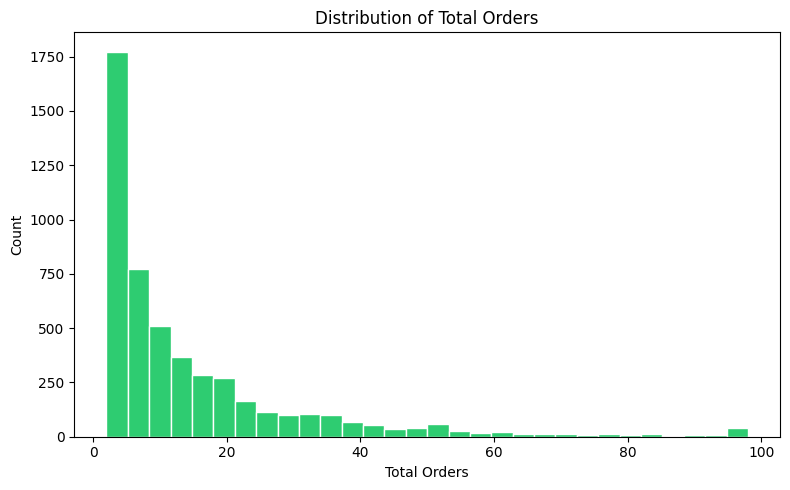

In [20]:
plt.figure(figsize=(8, 5))
plt.hist(df["total_orders"], bins=30, color="#2ECC71", edgecolor="white")
plt.title("Distribution of Total Orders")
plt.xlabel("Total Orders")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

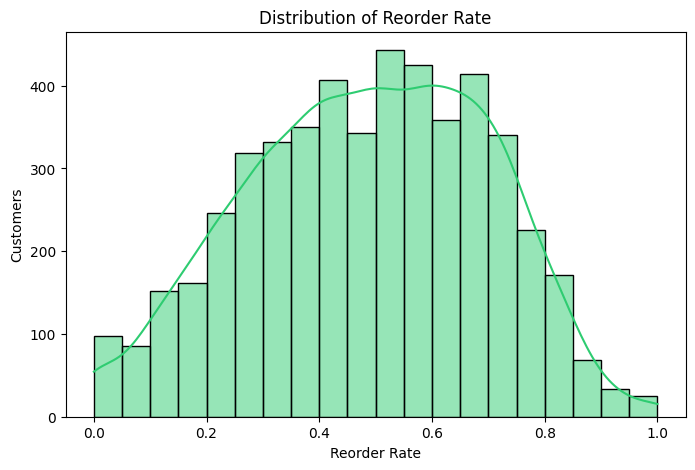

In [21]:
plt.figure(figsize=(8,5))

sns.histplot(
    customer_features["reorder_rate"],
    bins=20,
    kde=True,
    color="#2ECC71"
)

plt.title("Distribution of Reorder Rate")
plt.xlabel("Reorder Rate")
plt.ylabel("Customers")

plt.show()

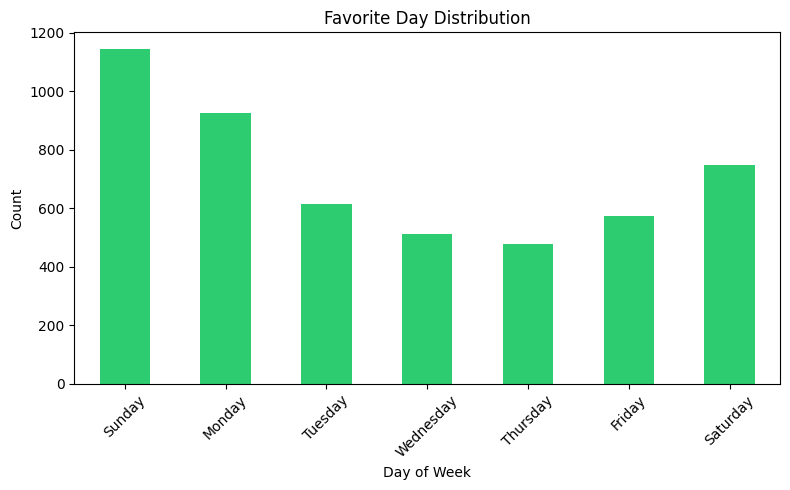

In [22]:
day_counts = df["favorite_day"].value_counts().sort_index()

day_names = {0: "Sunday", 1: "Monday", 2: "Tuesday", 3: "Wednesday",
             4: "Thursday", 5: "Friday", 6: "Saturday"}
day_counts.index = day_counts.index.map(day_names)

plt.figure(figsize=(8, 5))
day_counts.plot(kind="bar", color="#2ECC71")
plt.title("Favorite Day Distribution")
plt.xlabel("Day of Week")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

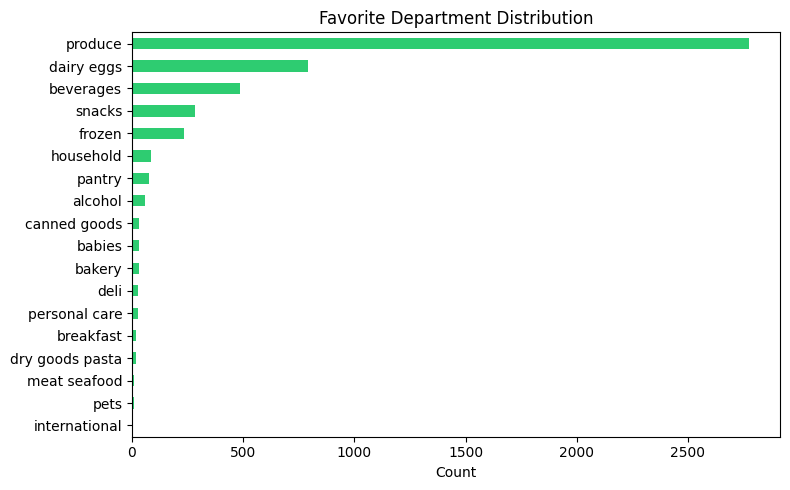

In [23]:
dept_counts = df["favorite_department"].value_counts().sort_values()

plt.figure(figsize=(8, 5))
dept_counts.plot(kind="barh", color="#2ECC71")
plt.title("Favorite Department Distribution")
plt.xlabel("Count")
plt.ylabel("")
plt.tight_layout()
plt.show()

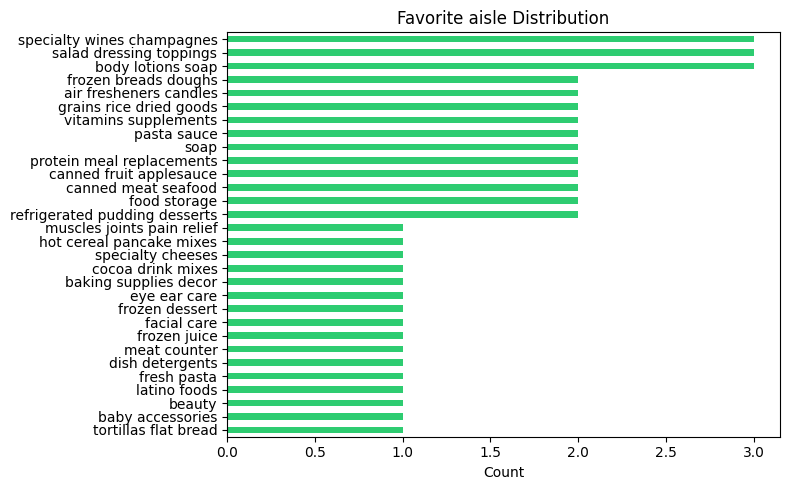

In [24]:
aisle_counts = df["favorite_aisle"].value_counts().sort_values().head(30)

plt.figure(figsize=(8, 5))
aisle_counts.plot(kind="barh", color="#2ECC71")
plt.title("Favorite aisle Distribution")
plt.xlabel("Count")
plt.ylabel("")
plt.tight_layout()
plt.show()

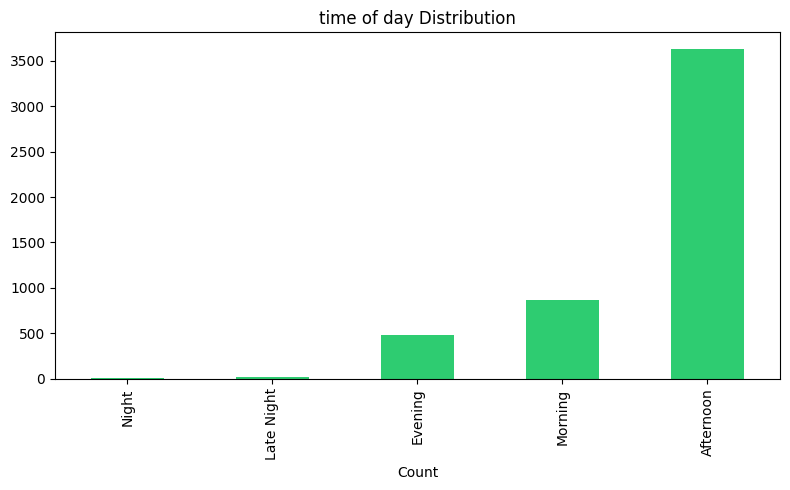

In [25]:
aisle_counts = df["time_of_day"].value_counts().sort_values().head(30)

plt.figure(figsize=(8, 5))
aisle_counts.plot(kind="bar", color="#2ECC71")
plt.title("time of day Distribution")
plt.xlabel("Count")
plt.ylabel("")
plt.tight_layout()
plt.show()

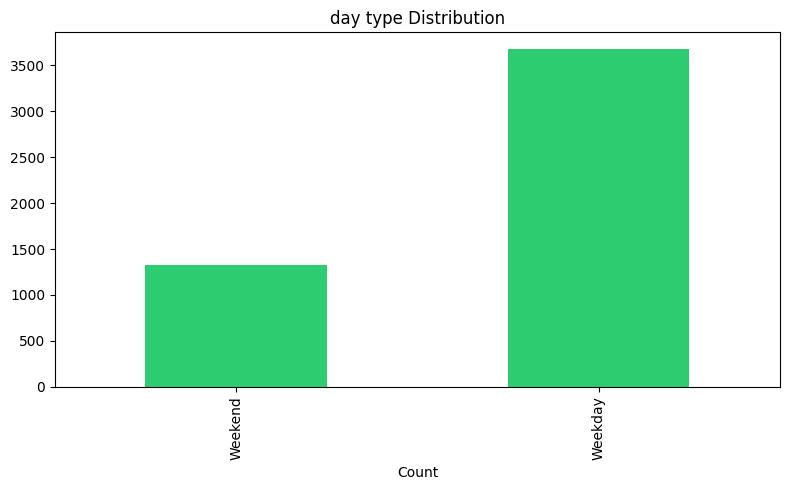

In [26]:
day_type_counts = df["day_type"].value_counts().sort_values().head(30)

plt.figure(figsize=(8, 5))
day_type_counts.plot(kind="bar", color="#2ECC71")
plt.title("day type Distribution")
plt.xlabel("Count")
plt.ylabel("")
plt.tight_layout()
plt.show()

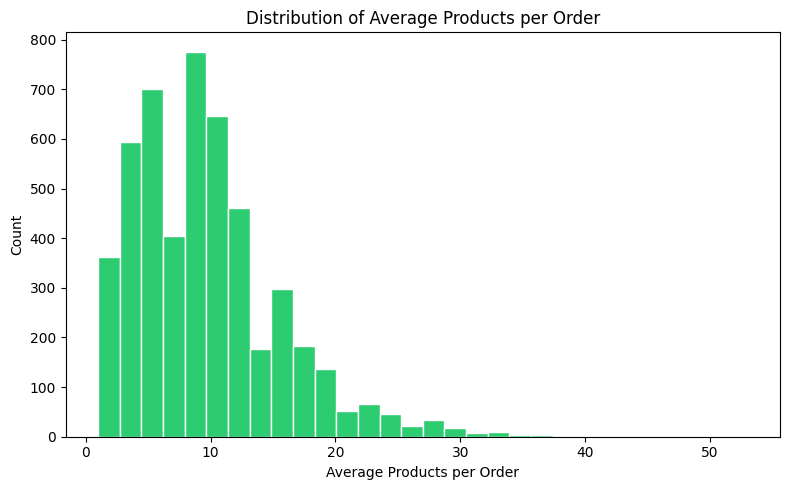

In [27]:
plt.figure(figsize=(8, 5))
plt.hist(df["avg_products_per_order"], bins=30, color="#2ECC71", edgecolor="white")
plt.title("Distribution of Average Products per Order")
plt.xlabel("Average Products per Order")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

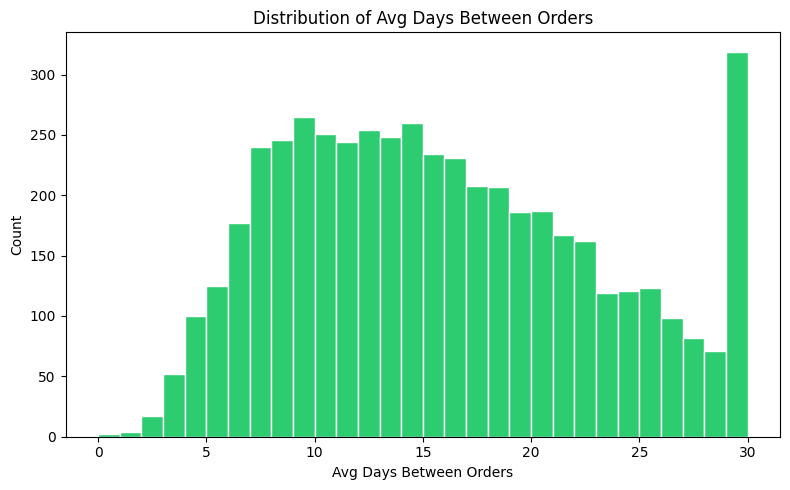

In [28]:
plt.figure(figsize=(8, 5))
plt.hist(df["avg_days_between_orders"], bins=30, color="#2ECC71", edgecolor="white")
plt.title("Distribution of Avg Days Between Orders")
plt.xlabel("Avg Days Between Orders")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

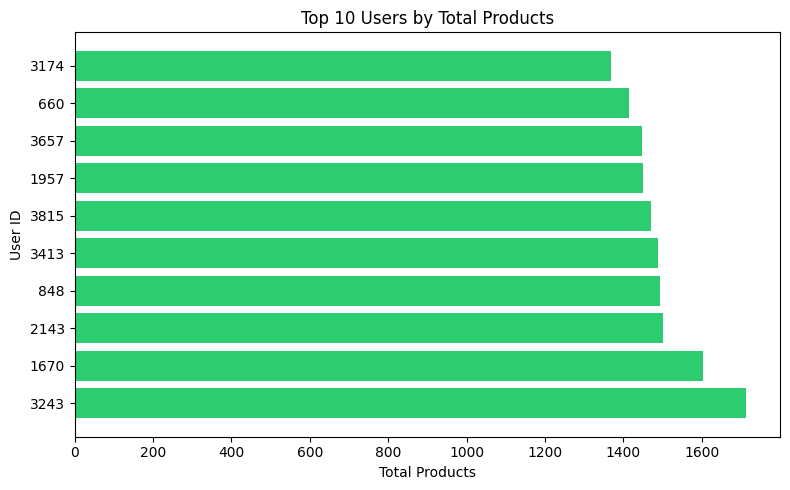

In [29]:
top10 = df.nlargest(10, "total_products")

plt.figure(figsize=(8, 5))
plt.barh(top10["user_id"].astype(str), top10["total_products"], color="#2ECC71")
plt.title("Top 10 Users by Total Products")
plt.xlabel("Total Products")
plt.ylabel("User ID")
plt.tight_layout()
plt.show()

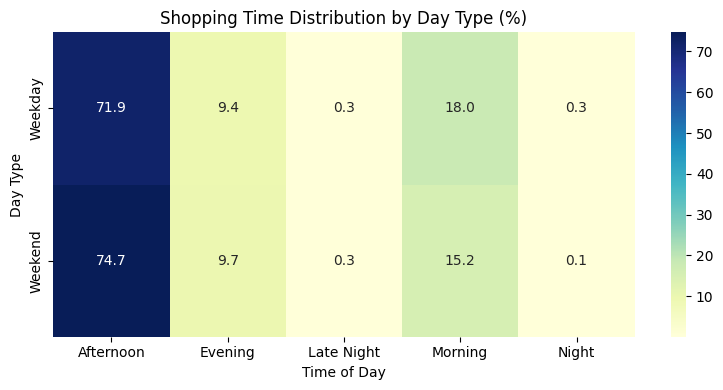

In [30]:
heatmap_data = pd.crosstab(
    df["day_type"],
    df["time_of_day"],
    normalize="index"
) * 100

plt.figure(figsize=(8, 4))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".1f",
    cmap="YlGnBu"
)

plt.title("Shopping Time Distribution by Day Type (%)")
plt.xlabel("Time of Day")
plt.ylabel("Day Type")

plt.tight_layout()
plt.show()

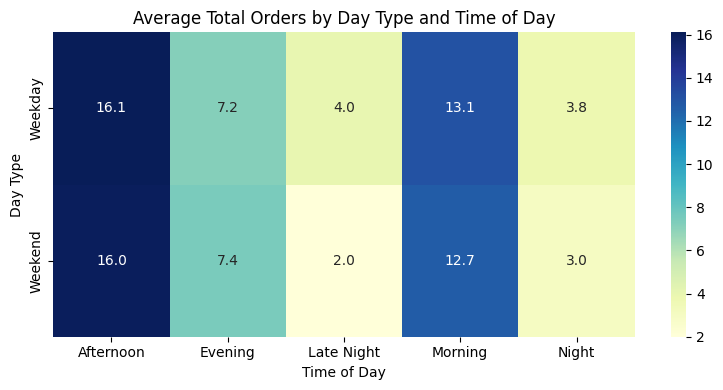

In [31]:
heatmap_data = df.pivot_table(
    values="total_orders",
    index="day_type",
    columns="time_of_day",
    aggfunc="mean"
)

plt.figure(figsize=(8, 4))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".1f",
    cmap="YlGnBu"
)

plt.title("Average Total Orders by Day Type and Time of Day")
plt.xlabel("Time of Day")
plt.ylabel("Day Type")

plt.tight_layout()
plt.show()

the day type is not a matter it's not affect on the oreders

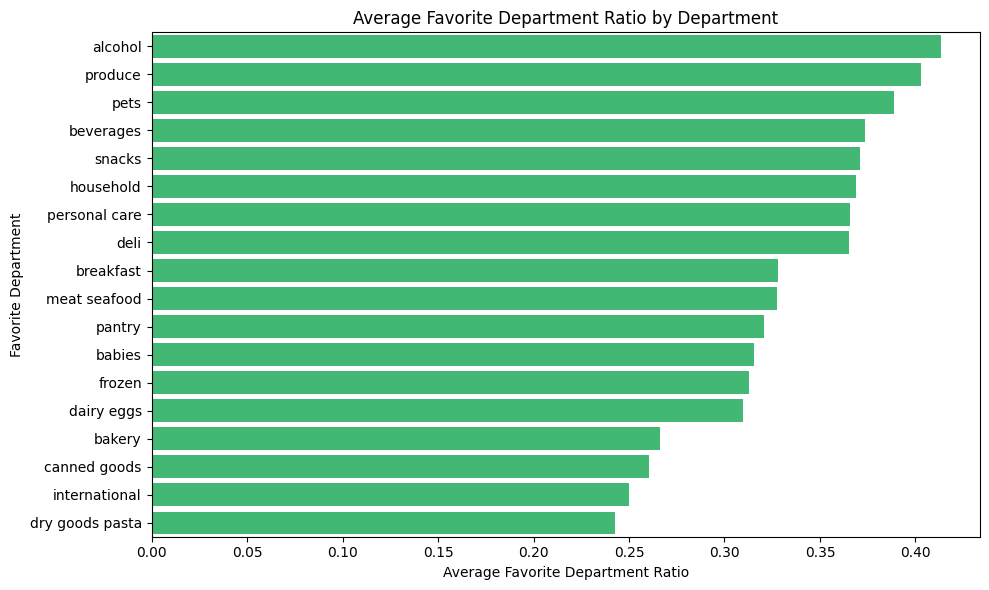

In [32]:
dept_ratio = (
    df
    .groupby("favorite_department")["favorite_dept_ratio"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=dept_ratio,
    y="favorite_department",
    x="favorite_dept_ratio",
    color="#2ECC71"
)

plt.title("Average Favorite Department Ratio by Department")
plt.xlabel("Average Favorite Department Ratio")
plt.ylabel("Favorite Department")

plt.tight_layout()
plt.show()

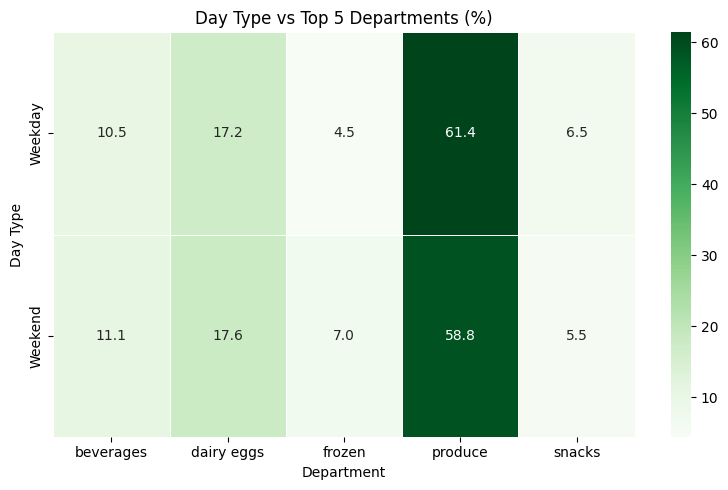

In [33]:
top5_depts = df["favorite_department"].value_counts().head(5).index
filtered = df[df["favorite_department"].isin(top5_depts)]

ct = pd.crosstab(filtered["day_type"], filtered["favorite_department"], normalize="index") * 100

plt.figure(figsize=(8, 5))
sns.heatmap(ct, annot=True, fmt=".1f", cmap="Greens", linewidths=0.5)
plt.title("Day Type vs Top 5 Departments (%)")
plt.xlabel("Department")
plt.ylabel("Day Type")
plt.tight_layout()
plt.show()

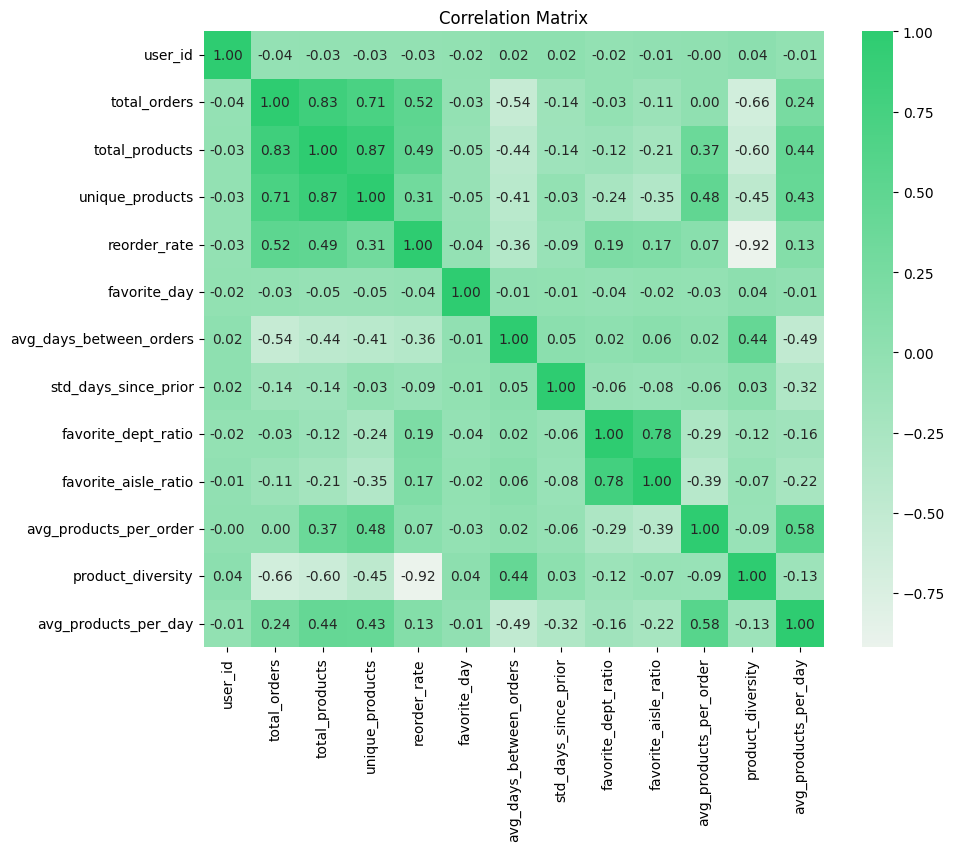

In [34]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df.select_dtypes(include="number").corr(),
    annot=True,
    cmap=sns.light_palette("#2ECC71", as_cmap=True),
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()

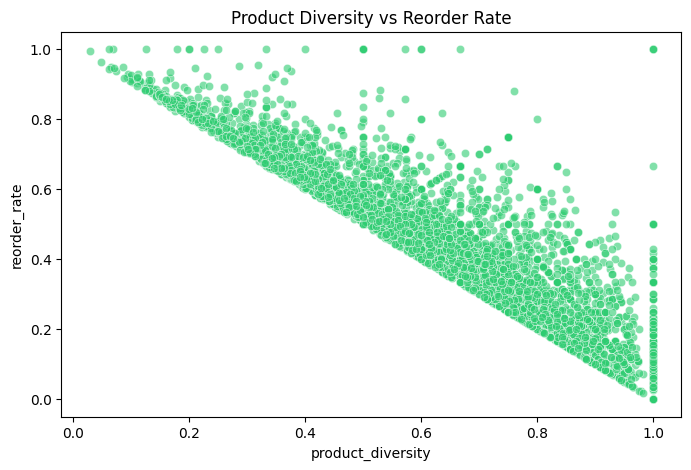

In [35]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="product_diversity",
    y="reorder_rate",
    color="#2ECC71",
    alpha=.6
)

plt.title("Product Diversity vs Reorder Rate")

plt.show()

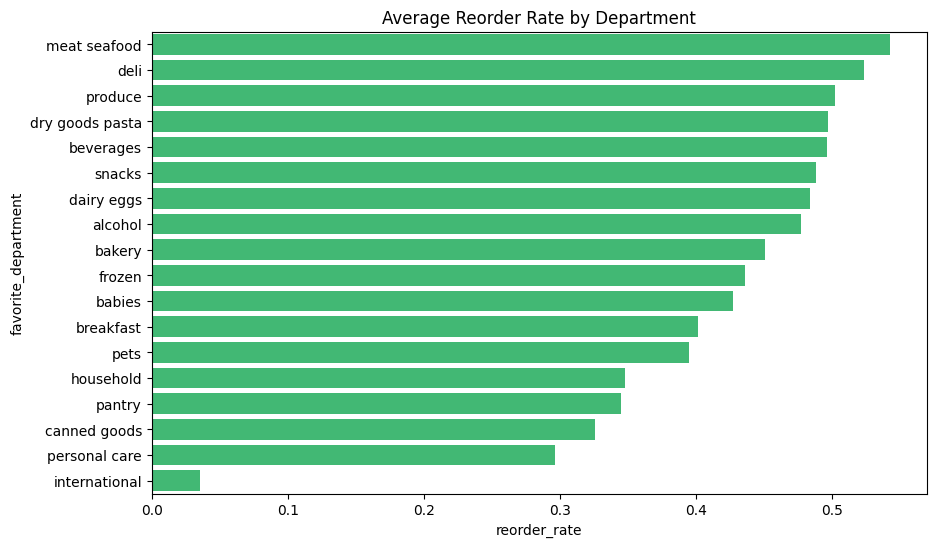

In [36]:
dept_reorder = (
    df
    .groupby("favorite_department")["reorder_rate"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=dept_reorder,
    y="favorite_department",
    x="reorder_rate",
    color="#2ECC71"
)

plt.title("Average Reorder Rate by Department")

plt.show()

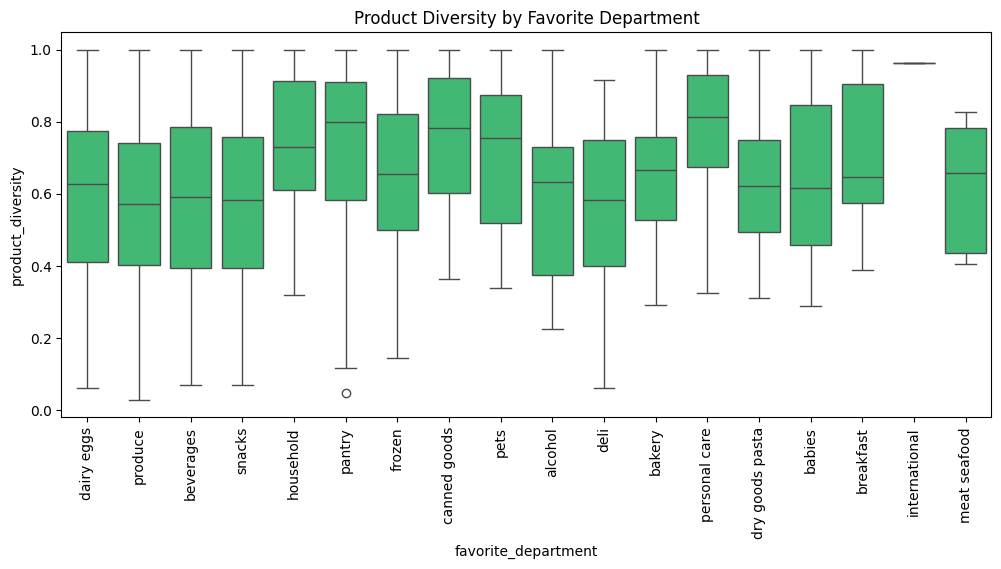

In [37]:
plt.figure(figsize=(12,5))

sns.boxplot(
    data=df,
    x="favorite_department",
    y="product_diversity",
    color="#2ECC71"
)

plt.xticks(rotation=90)

plt.title("Product Diversity by Favorite Department")

plt.show()

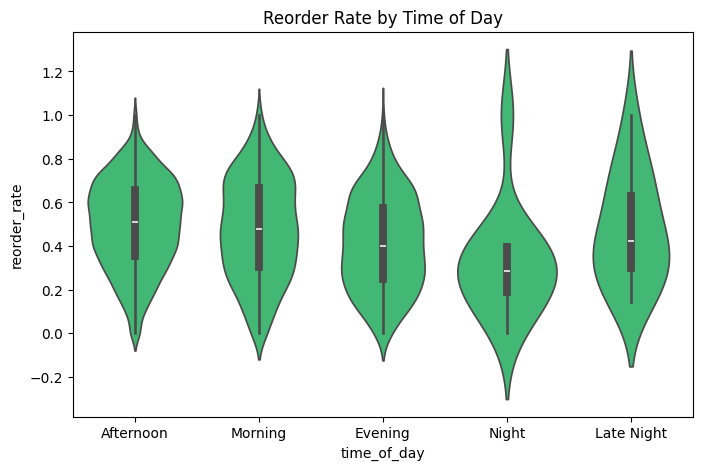

In [38]:
plt.figure(figsize=(8,5))

sns.violinplot(
    data=df,
    x="time_of_day",
    y="reorder_rate",
    color="#2ECC71"
)

plt.title("Reorder Rate by Time of Day")

plt.show()

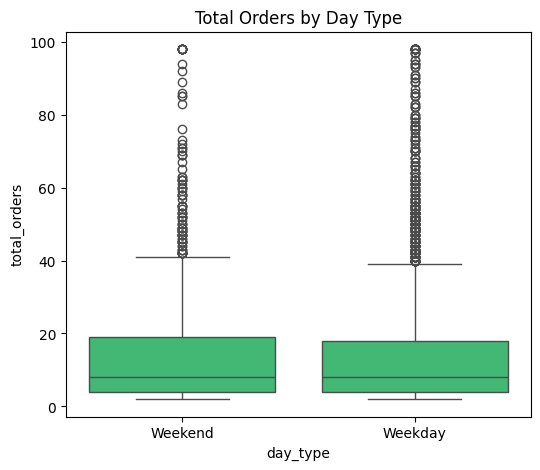

In [39]:
plt.figure(figsize=(6,5))

sns.boxplot(
    data=df,
    x="day_type",
    y="total_orders",
    color="#2ECC71"
)

plt.title("Total Orders by Day Type")

plt.show()

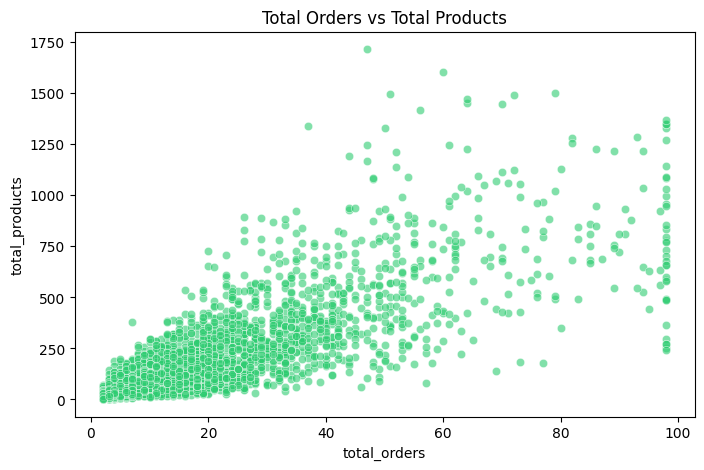

In [40]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=customer_features,
    x="total_orders",
    y="total_products",
    color="#2ECC71",
    alpha=.6
)

plt.title("Total Orders vs Total Products")

plt.show()

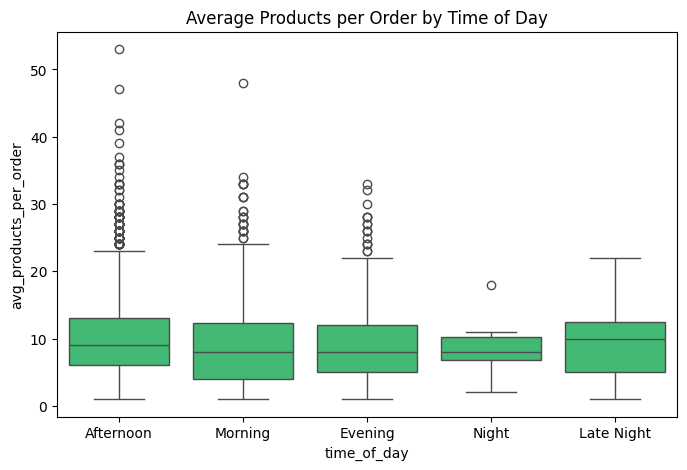

In [41]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="time_of_day",
    y="avg_products_per_order",
    color="#2ECC71"
)

plt.title("Average Products per Order by Time of Day")

plt.show()

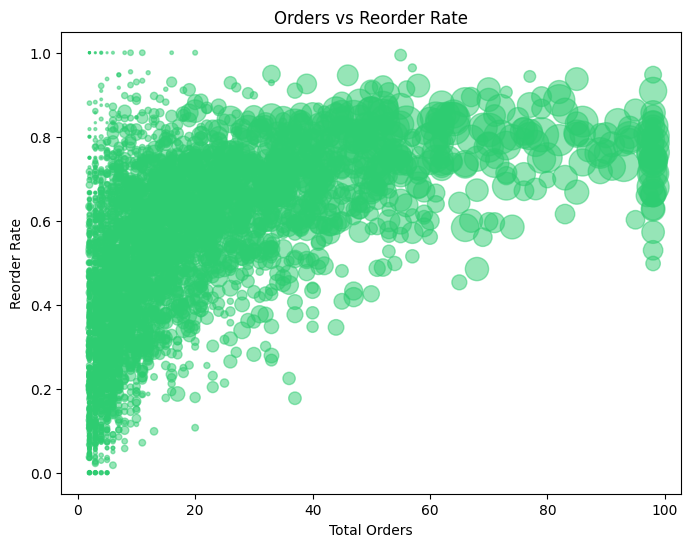

In [42]:
plt.figure(figsize=(8,6))

plt.scatter(
    df["total_orders"],
    df["reorder_rate"],
    s=df["total_products"]*0.4,
    color="#2ECC71",
    alpha=.5
)

plt.xlabel("Total Orders")
plt.ylabel("Reorder Rate")
plt.title("Orders vs Reorder Rate")

plt.show()

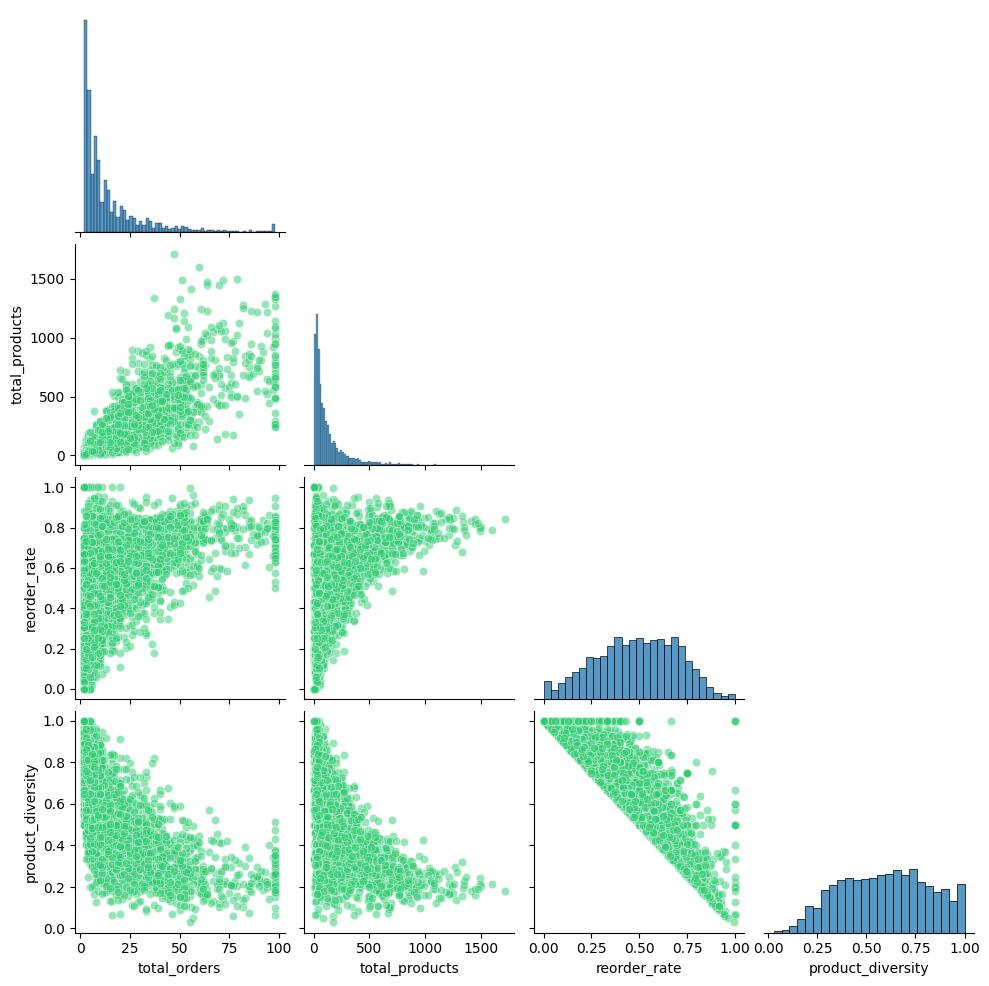

In [43]:
cols = [
    "total_orders",
    "total_products",
    "reorder_rate",
    "product_diversity"
]

sns.pairplot(
    df[cols],
    corner=True,
    plot_kws={"color":"#2ECC71","alpha":0.5}
)

plt.show()

# Encoding

In [44]:
X=df.drop(columns=["user_id"])

In [45]:
for I in X.select_dtypes(include=["object"]).columns.tolist():
    print(I," ",X[I].nunique())

favorite_department   18
favorite_aisle   109
time_of_day   5
day_type   2


In [46]:
# One-Hot
one_hot_cols = [
    "favorite_department",
    "time_of_day",
    "day_type"
]

# Frequency Encoding
freq = X["favorite_aisle"].value_counts(normalize=True)
X["favorite_aisle"] = X["favorite_aisle"].map(freq)

# One-Hot
X = pd.get_dummies(X, columns=one_hot_cols, drop_first=False)

In [47]:
bool_cols = X.select_dtypes(include=["bool"]).columns
X[bool_cols] = X[bool_cols].astype(int)

In [48]:
X.head()

,total_orders,total_products,unique_products,reorder_rate,favorite_day,avg_days_between_orders,favorite_aisle,std_days_since_prior,favorite_dept_ratio,favorite_aisle_ratio,...,favorite_department_pets,favorite_department_produce,favorite_department_snacks,time_of_day_Afternoon,time_of_day_Evening,time_of_day_Late Night,time_of_day_Morning,time_of_day_Night,day_type_Weekday,day_type_Weekend
1,2,18,15,0.277778,5,16,0.0480,1.843554,0.444444,0.277778,...,0,0,0,1,0,0,0,0,0,1
2,14,206,82,0.611650,4,9,0.0088,8.847593,0.199029,0.116505,...,0,0,0,1,0,0,0,0,1,0
3,19,152,79,0.552632,5,15,0.0480,9.620645,0.368421,0.138158,...,0,1,0,1,0,0,0,0,0,1
4,2,4,3,0.750000,2,18,0.0060,2.000000,1.000000,0.500000,...,0,0,0,0,0,0,1,0,1,0
5,3,28,26,0.214286,2,4,0.2534,1.643892,0.250000,0.142857,...,0,0,1,1,0,0,0,0,1,0


# Scaling

In [49]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [50]:
X_scaled

array([[-0.75208087, -0.6490737 , -0.82335304, ..., -0.04904869,
        -1.6662638 ,  1.6662638 ],
       [-0.03727702,  0.29057553,  0.37261305, ..., -0.04904869,
         0.60014507, -0.60014507],
       [ 0.26055792,  0.02067628,  0.31906233, ..., -0.04904869,
        -1.6662638 ,  1.6662638 ],
       ...,
       [-0.75208087, -0.71904758, -1.01970568, ..., -0.04904869,
        -1.6662638 ,  1.6662638 ],
       [-0.69251389, -0.66406811, -0.85905352, ..., -0.04904869,
         0.60014507, -0.60014507],
       [-0.51381292, -0.54911102, -0.51989896, ..., -0.04904869,
        -1.6662638 ,  1.6662638 ]], shape=(5000, 38))

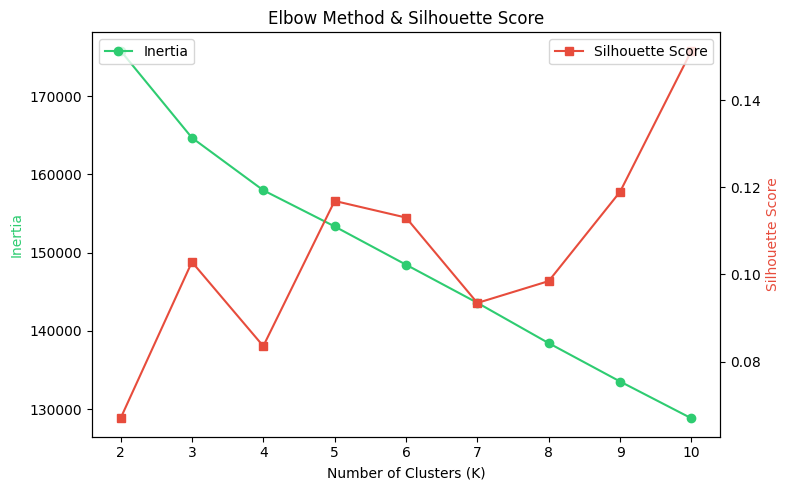

In [51]:
inertia = []
silhouette = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)
    silhouette.append(silhouette_score(X_scaled, kmeans.labels_))

fig, ax1 = plt.subplots(figsize=(8, 5))

ax1.plot(K_range, inertia, "o-", color="#2ECC71", label="Inertia")
ax1.set_xlabel("Number of Clusters (K)")
ax1.set_ylabel("Inertia", color="#2ECC71")
ax1.legend(loc="upper left")

ax2 = ax1.twinx()
ax2.plot(K_range, silhouette, "s-", color="#E74C3C", label="Silhouette Score")
ax2.set_ylabel("Silhouette Score", color="#E74C3C")
ax2.legend(loc="upper right")

plt.title("Elbow Method & Silhouette Score")
plt.tight_layout()
plt.show()

In [52]:
for k in [3,4,5, 6,10]:
    model = KMeans(n_clusters=k, random_state=42)
    labels = model.fit_predict(X_scaled)

    print(f"K={k}")
    print("Silhouette:", silhouette_score(X_scaled, labels))
    print(pd.Series(labels).value_counts().sort_index())
    print("-"*40)

K=3
Silhouette: 0.10285888002751821
0    1220
1     832
2    2948
Name: count, dtype: int64
----------------------------------------
K=4
Silhouette: 0.11765433520668649
0     230
1     786
2    2846
3    1138
Name: count, dtype: int64
----------------------------------------
K=5
Silhouette: 0.12414531481348147
0     230
1     780
2    2830
3    1128
4      32
Name: count, dtype: int64
----------------------------------------
K=6
Silhouette: 0.1279499839280516
0     230
1    2041
2     921
3    1128
4      32
5     648
Name: count, dtype: int64
----------------------------------------
K=10
Silhouette: 0.13373171995188832
0     230
1     556
2    1110
3      32
4     425
5    1518
6     995
7      28
8      29
9      77
Name: count, dtype: int64
----------------------------------------


In [53]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

df["Cluster"] = clusters

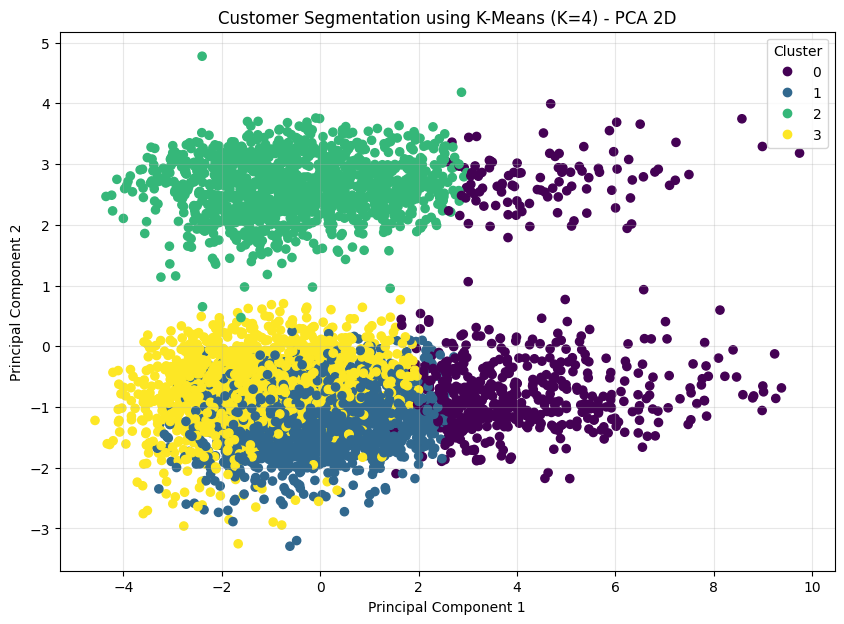

In [54]:

# Reduce to 2 dimensions
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10,7))

scatter = plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=df["Cluster"],
    cmap="viridis",
    s=35
)

plt.title("Customer Segmentation using K-Means (K=4) - PCA 2D")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(*scatter.legend_elements(), title="Cluster")
plt.grid(alpha=0.3)

plt.show()

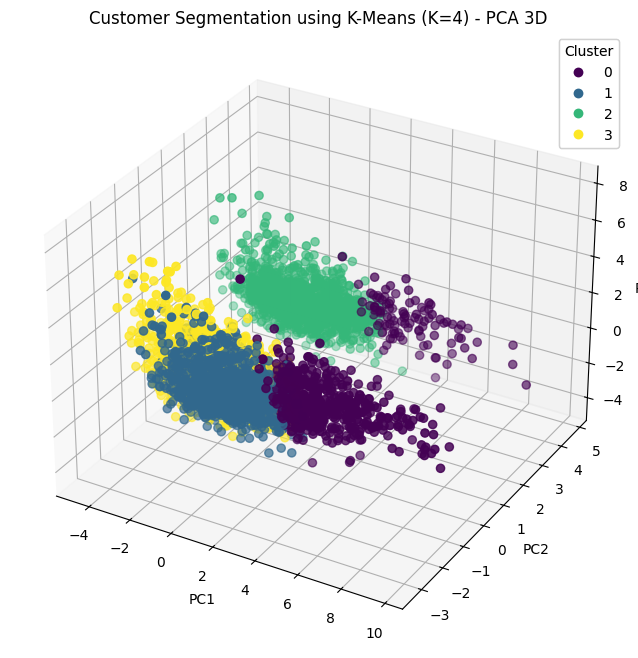

In [55]:
from mpl_toolkits.mplot3d import Axes3D
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Reduce to 3 dimensions
pca = PCA(n_components=3, random_state=42)
X_pca_3d = pca.fit_transform(X_scaled)

fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    X_pca_3d[:,0],
    X_pca_3d[:,1],
    X_pca_3d[:,2],
    c=df["Cluster"],
    cmap="viridis",
    s=35
)

ax.set_title("Customer Segmentation using K-Means (K=4) - PCA 3D")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")

legend = ax.legend(*scatter.legend_elements(), title="Cluster")
ax.add_artist(legend)

plt.show()

In [56]:
cluster_summary = df.groupby("Cluster").mean(numeric_only=True)
cluster_summary

,user_id,total_orders,total_products,unique_products,reorder_rate,favorite_day,avg_days_between_orders,std_days_since_prior,favorite_dept_ratio,favorite_aisle_ratio,avg_products_per_order,product_diversity,avg_products_per_day
Cluster,,,,,,,,,,,,,
0,2410.877193,46.813397,569.521531,163.800638,0.708421,2.073365,7.802233,4.872298,0.354837,0.179167,13.277512,0.313579,2.001079
1,2498.543660,9.828947,93.388756,50.803828,0.455935,1.409091,16.603469,7.046384,0.411443,0.224949,10.061005,0.629693,0.941499
2,2468.099262,11.401969,100.855619,51.473339,0.456121,5.570139,15.861362,6.729671,0.360601,0.209500,9.353568,0.626286,0.953202
3,2567.275304,9.071525,69.593117,37.270580,0.448787,1.707827,17.009447,6.782702,0.349917,0.226978,7.772605,0.647736,0.776946


## Choosing the Optimal Number of Clusters (K)

To determine the optimal number of clusters, both the **Elbow Method** and the **Silhouette Score** were evaluated.

### Elbow Method
The inertia curve showed a noticeable reduction up to **K = 4**, after which the improvement became more gradual. This indicates diminishing returns when increasing the number of clusters.

### Silhouette Score
Although the highest Silhouette Score was achieved at larger values of K (such as K = 10), the improvement over **K = 4** was relatively small.

### Cluster Distribution
For higher values of K (5, 6, and 10), very small clusters appeared (e.g., clusters containing only 29–32 customers). Such tiny clusters are difficult to interpret and provide limited business value.

In contrast, **K = 4** produced a more balanced segmentation while maintaining a competitive Silhouette Score.

### Final Decision
Therefore, **K = 4** was selected because it provides the best trade-off between:

- Good cluster separation.
- Balanced cluster sizes.
- Simpler and more interpretable customer segments.
- Practical business insights suitable for customer segmentation.

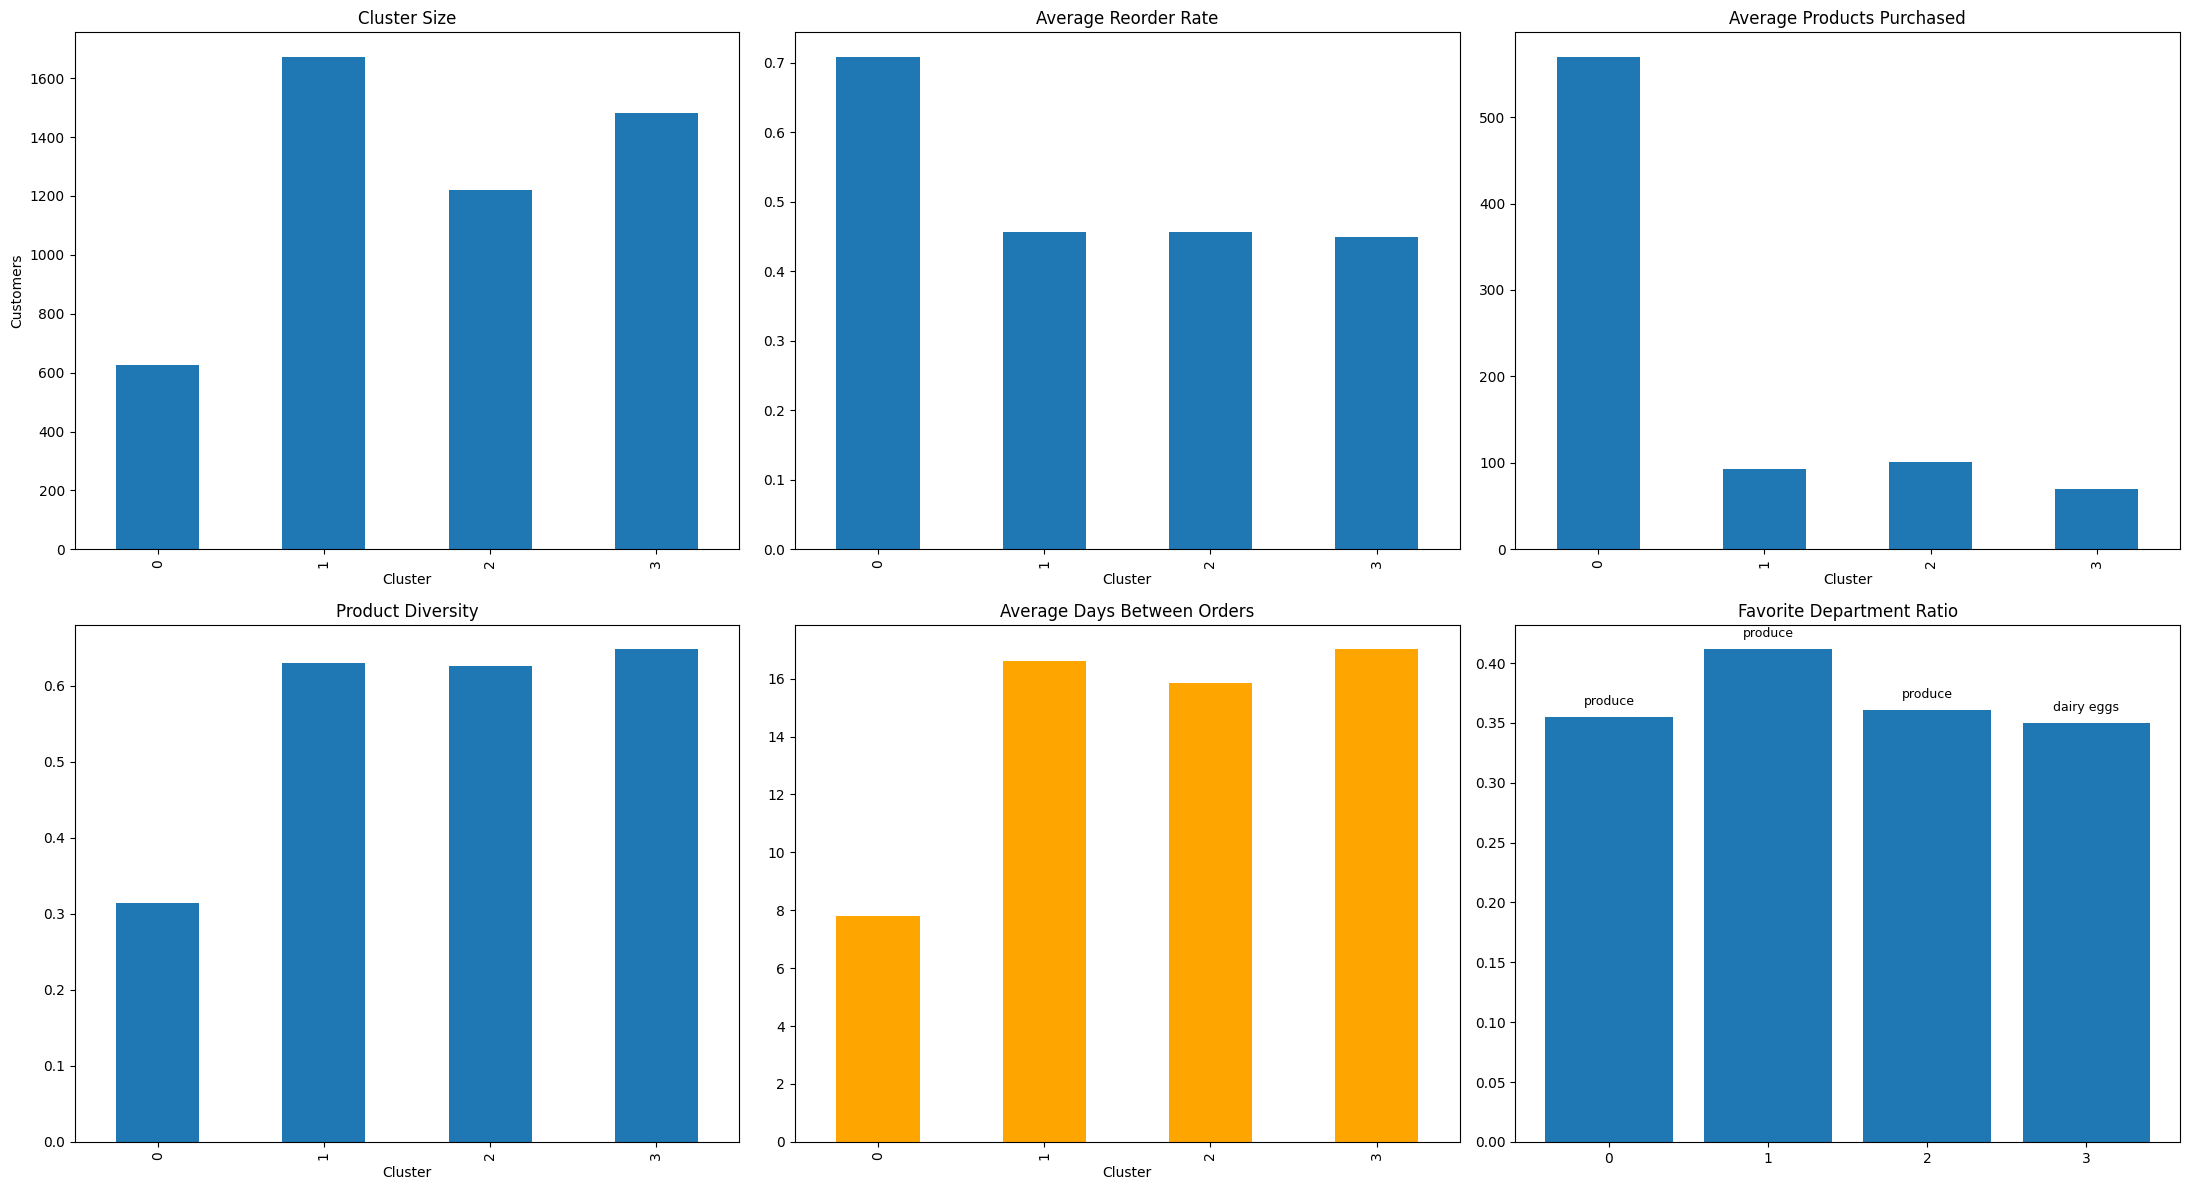

In [62]:
fig, axes = plt.subplots(2, 3, figsize=(22, 12))

cluster_summary = df.groupby("Cluster").agg({
    "total_orders":"mean",
    "total_products":"mean",
    "avg_products_per_order":"mean",
    "reorder_rate":"mean",
    "product_diversity":"mean",
    "avg_days_between_orders":"mean",
    "favorite_dept_ratio":"mean"
})

# ===========================
# 1. Cluster Size
# ===========================

df["Cluster"].value_counts().sort_index().plot(
    kind="bar",
    ax=axes[0,0]
)

axes[0,0].set_title("Cluster Size")
axes[0,0].set_ylabel("Customers")

# ===========================
# 2. Loyalty
# ===========================

cluster_summary["reorder_rate"].plot(
    kind="bar",
    ax=axes[0,1]
)

axes[0,1].set_title("Average Reorder Rate")

# ===========================
# 3. Consumption
# ===========================

cluster_summary["total_products"].plot(
    kind="bar",
    ax=axes[0,2]
)

axes[0,2].set_title("Average Products Purchased")

# ===========================
# 4. Product Diversity
# ===========================

cluster_summary["product_diversity"].plot(
    kind="bar",
    ax=axes[1,0]
)

axes[1,0].set_title("Product Diversity")

# ===========================
# 5. Shopping Frequency
# ===========================

cluster_summary["avg_days_between_orders"].plot(
    kind="bar",
    ax=axes[1,1],
    color="orange"
)

axes[1,1].set_title("Average Days Between Orders")

# ===========================
# 6. Favorite Department
# ===========================

favorite = (
    df.groupby("Cluster")
      .agg({
          "favorite_department":lambda x:x.mode()[0],
          "favorite_dept_ratio":"mean"
      })
)

axes[1,2].bar(
    favorite.index.astype(str),
    favorite["favorite_dept_ratio"]
)

for i,row in enumerate(favorite.itertuples()):

    axes[1,2].text(
        i,
        row.favorite_dept_ratio+0.01,
        row.favorite_department,
        ha="center",
        fontsize=9
    )

axes[1,2].set_title("Favorite Department Ratio")

plt.tight_layout()
plt.show()